### generate multilabel confusion matrix with data input from excel assessment of results
need to work on staying in python and not excel

In [1]:
pip install -U scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 20.5 MB/s  0:00:00m0:00:0100:01
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 26.1.1 -> 26.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [20]:
pip install -U seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)

[notice] A new release of pip is available: 26.1.1 -> 26.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
from sklearn.metrics import multilabel_confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import mean_squared_error
import seaborn as sns
import pandas as pd



In [4]:
# ground truth
gt_train_rpts = pd.read_excel(io='/Users/elisabethwatson/Documents/GitHub/ADSCert_project_Watson/bondsAllocsJune7.xlsx', sheet_name='ground_truth_train', dtype={'pdfname': str, "gt_source": str, "ES_0_percent": bool, "ES_100_percent": bool, "ES_partial": bool, "number_of_cats": int})
gt_train_df = pd.DataFrame(gt_train_rpts)
gt_train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   pdfname         34 non-null     str  
 1   gt_source       34 non-null     str  
 2   ES_0_percent    34 non-null     bool 
 3   ES_100_percent  34 non-null     bool 
 4   ES_partial      34 non-null     bool 
 5   number_of_cats  34 non-null     int64
dtypes: bool(3), int64(1), str(2)
memory usage: 2.5 KB


In [5]:
# create y_true based on ES percent cols
ES_percent_true = []
for r in gt_train_df.itertuples(index=False):
    if r.ES_0_percent:
        ES_percent_true.append('ES 0%')
    elif r.ES_100_percent:
        ES_percent_true.append('ES 100%')
    elif r.ES_partial:
        ES_percent_true.append('ES partial')
gt_train_df['ES_percent_true'] = ES_percent_true

In [8]:
# pipeline predictions
pred_train_rpts = pd.read_csv('/Users/elisabethwatson/Documents/GitHub/ADSCert_project_Watson/Output_DataFrames/pred_train_rpts_V4.csv')
pred_train_df = pd.DataFrame(pred_train_rpts)
pred_train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   pdfname               34 non-null     str    
 1   nlp_path              34 non-null     str    
 2   language              34 non-null     str    
 3   similarity_threshold  34 non-null     float64
 4   cleanup_threshold     34 non-null     float64
 5   ES_0_percent          34 non-null     bool   
 6   ES_100_percent        34 non-null     bool   
 7   ES_partial            34 non-null     bool   
 8   number_of_cats        34 non-null     int64  
dtypes: bool(3), float64(2), int64(1), str(3)
memory usage: 3.5 KB


In [9]:
# create y_pred based on ES percent cols
ES_percent_pred = []
for r in pred_train_df.itertuples(index=False):
    if r.ES_0_percent:
        ES_percent_pred.append('ES 0%')
    elif r.ES_100_percent:
        ES_percent_pred.append('ES 100%')
    elif r.ES_partial:
        ES_percent_pred.append('ES partial')
pred_train_df['ES_percent_pred'] = ES_percent_pred


In [30]:
# create a dataset containing results for confusion matrix

conf_mtrx_df = pd.DataFrame()

conf_mtrx_df['pdfname'] = pred_train_df['pdfname']
conf_mtrx_df['gt_source'] = gt_train_df['gt_source']
conf_mtrx_df['nlp_path'] = pred_train_df['nlp_path']
conf_mtrx_df['language'] = pred_train_df['language']
conf_mtrx_df['similarity_th'] = pred_train_df['similarity_threshold']
conf_mtrx_df['cleanup_th'] = pred_train_df['cleanup_threshold']
conf_mtrx_df['ES_percent_true'] = gt_train_df['ES_percent_true']
conf_mtrx_df['ES_percent_pred'] = pred_train_df['ES_percent_pred']
conf_mtrx_df['num_cats_true'] = gt_train_df['number_of_cats']
conf_mtrx_df['num_cats_pred'] = pred_train_df['number_of_cats']
conf_mtrx_df['num_cats_diff'] = conf_mtrx_df['num_cats_true'] - conf_mtrx_df['num_cats_pred']

conf_mtrx_df

,pdfname,gt_source,nlp_path,language,similarity_th,cleanup_th,ES_percent_true,ES_percent_pred,num_cats_true,num_cats_pred,num_cats_diff
0,Climate_Bond_Framework_of_E1_SUBHOLDING_S_A__i...,manual,UOP_section_true,EN,0.65,0.65,ES partial,ES partial,6,3,3
1,Chile_Sustainable_Bond_Framework,manual,Table,EN,0.65,0.65,ES 0%,ES partial,0,8,-8
2,Genneia_Green_Financing_Framework,manual,Table,EN,0.65,0.65,ES partial,ES 100%,5,1,4
3,Marco_de_Uso_de_Fondo_para_la_Emision_de_Bonos...,manual,Table,ES,0.65,0.65,ES partial,ES 100%,7,1,6
4,Green_Bond_Framework,manual,Table,PT,0.65,0.65,ES partial,ES partial,13,2,11
5,Green_Bonds_Framework_Athon_2020,manual,UOP_section_true,PT,0.65,0.65,ES partial,ES partial,4,9,-5
6,Cartilla_Bonos_Verdes,manual,UOP_section_true,ES,0.65,0.65,ES 0%,ES partial,0,10,-10
7,Bono_Azul_-_Framework,manual,UOP_section_true,ES,0.65,0.65,ES partial,ES 0%,6,5,1
8,Marco_de_referencia_de_bono_verde_Coopeguanaca...,manual,UOP_section_true,ES,0.65,0.65,ES partial,ES partial,8,9,-1
9,Marco_de_Referencia_del_Bono_Verde_de_la_Ciuda...,manual,UOP_section_false,ES,0.65,0.65,ES partial,ES partial,17,10,7


In [31]:
# create ES Partial TP col based on ES percent cols
ES_partial_True_Positives = []
for r in conf_mtrx_df.itertuples(index=False):
    if r.ES_percent_true == 'ES partial' and r.ES_percent_pred == 'ES partial':
        ES_partial_True_Positives.append(True)
    else:
        ES_partial_True_Positives.append(False)
conf_mtrx_df['ES_partial_True_Positives'] = ES_partial_True_Positives
conf_mtrx_df['ES_partial_True_Positives'].value_counts()
conf_mtrx_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   pdfname                    34 non-null     str    
 1   gt_source                  34 non-null     str    
 2   nlp_path                   34 non-null     str    
 3   language                   34 non-null     str    
 4   similarity_th              34 non-null     float64
 5   cleanup_th                 34 non-null     float64
 6   ES_percent_true            34 non-null     str    
 7   ES_percent_pred            34 non-null     str    
 8   num_cats_true              34 non-null     int64  
 9   num_cats_pred              34 non-null     int64  
 10  num_cats_diff              34 non-null     int64  
 11  ES_partial_True_Positives  34 non-null     bool   
dtypes: bool(1), float64(2), int64(3), str(6)
memory usage: 5.5 KB


In [55]:
# bring in data from eval

y_true = conf_mtrx_df['ES_percent_true']
y_pred = conf_mtrx_df['ES_percent_pred']
labels = ['ES 0%', 'ES 100%', 'ES partial']
multilabel_confusion_matrix(y_true, y_pred, labels=labels)

array([[[28,  2],
        [ 4,  0]],

       [[20,  3],
        [10,  1]],

       [[ 1, 14],
        [ 5, 14]]])

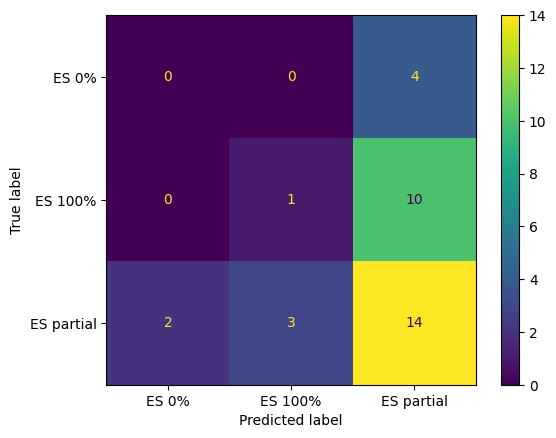

In [52]:
cm = multilabel_confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
plt.show()

In [56]:
accuracy_score_frac = accuracy_score(y_true, y_pred)
accuracy_score_num = accuracy_score(y_true, y_pred, normalize=False)

print(accuracy_score_frac, accuracy_score_num)

f1_score(y_true, y_pred, average='macro')

0.4411764705882353 15.0


0.24302600472813238

In [33]:
# create a dataset containing results for boxplots

boxplot_df = conf_mtrx_df.query("ES_partial_True_Positives == True")
boxplot_df.info()


<class 'pandas.DataFrame'>
Index: 14 entries, 0 to 32
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   pdfname                    14 non-null     str    
 1   gt_source                  14 non-null     str    
 2   nlp_path                   14 non-null     str    
 3   language                   14 non-null     str    
 4   similarity_th              14 non-null     float64
 5   cleanup_th                 14 non-null     float64
 6   ES_percent_true            14 non-null     str    
 7   ES_percent_pred            14 non-null     str    
 8   num_cats_true              14 non-null     int64  
 9   num_cats_pred              14 non-null     int64  
 10  num_cats_diff              14 non-null     int64  
 11  ES_partial_True_Positives  14 non-null     bool   
dtypes: bool(1), float64(2), int64(3), str(6)
memory usage: 2.4 KB


<Axes: xlabel='num_cats_diff', ylabel='gt_source'>

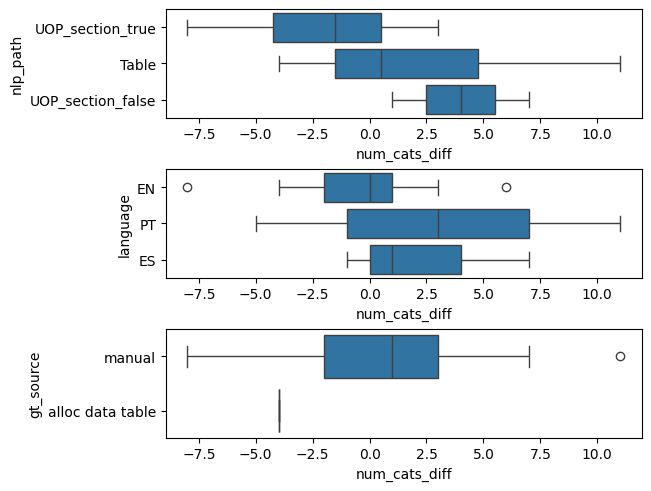

In [52]:
fig, axes = plt.subplots(3,1, layout = 'constrained')

sns.boxplot(x=boxplot_df['num_cats_diff'], y = boxplot_df['nlp_path'], ax=axes[0])
sns.boxplot(x=boxplot_df['num_cats_diff'], y = boxplot_df['language'], ax=axes[1])
sns.boxplot(x=boxplot_df['num_cats_diff'], y = boxplot_df['gt_source'], ax=axes[2])

In [54]:
conf_mtrx_df.describe()

,similarity_th,cleanup_th,num_cats_true,num_cats_pred,num_cats_diff
count,3.400000e+01,3.400000e+01,34.000000,34.000000,34.000000
mean,6.500000e-01,6.500000e-01,3.294118,4.882353,-1.588235
std,1.126919e-16,1.126919e-16,4.310167,3.160022,5.488929
min,6.500000e-01,6.500000e-01,0.000000,1.000000,-10.000000
25%,6.500000e-01,6.500000e-01,0.000000,2.000000,-5.000000
50%,6.500000e-01,6.500000e-01,2.000000,4.000000,-2.000000
75%,6.500000e-01,6.500000e-01,5.750000,7.000000,1.000000
max,6.500000e-01,6.500000e-01,17.000000,10.000000,11.000000
